In [3]:
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint_adjoint as odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")


/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/torch/cuda/__init__.py:749: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [51]:
def load_model_and_data(ckpt_path, n_dimension):
    """
    from relative path, detect training setting and load data
    """
    global n_timepoint 
    global cellstate_key

    model_name = ckpt_path.split("/")[2].replace("_tsense","")
    model_class = eval(f"models.{model_name}")
    # MODEL CLASS and define model
    pde_model = model_class.load_from_checkpoint(ckpt_path)


    data_name = ckpt_path.split("/")[1].split("-")[0]
    adata = sc.read_h5ad(f"data/{data_name}.h5ad")
    
    cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
    n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])
    # the DS
    dataset = reader.TwoTimpepoint_AnnDS(AnnData=adata, n_timepoint=n_timepoint,  
                                n_dimension = n_dimension,
                                cellstate_key=cellstate_key,  #'DM_EigenVector'
                                log_transform=False,
                                norm_time=False,
                                batchsize = 300
                                )

    return pde_model, dataset, adata

In [52]:
# CHANG THIS !!!!!
ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_7/checkpoints/epoch=125-total_loss=0.02699740.ckpt"

model, train_DS, adata = load_model_and_data(ckpt_path, 5)

In [57]:
u_b = train_DS.u_b.numpy().reshape(n_timepoint, -1)
print(u_b.shape)

(3, 47907)


# cellstate and duds

In [16]:
select_cb = {}

for ct in adata.obs['label_man'].unique():
    cb = np.random.choice(adata.obs.query("`label_man` == @ct").index)
    select_cb[ct] = cb
    
select_adata = adata[list(select_cb.values())]
select_adata

View of AnnData object with n_obs × n_vars = 22 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'Day2_u', 'Day4_u', 'Day6_u'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'pop', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

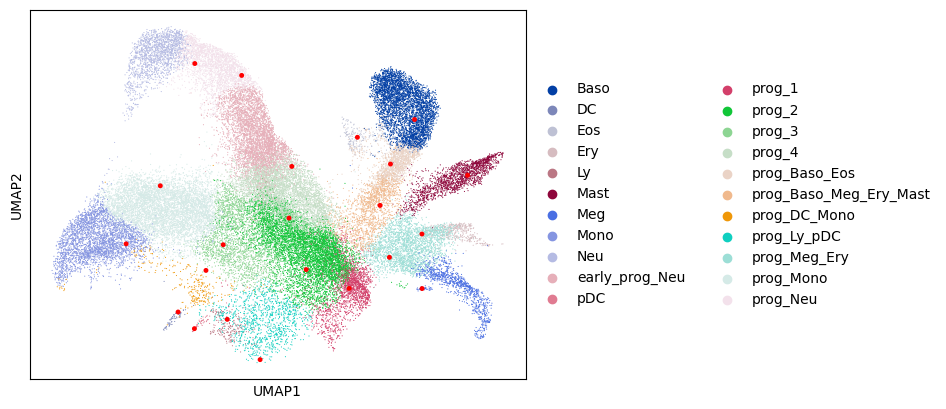

In [14]:
fig = sc.pl.umap(adata, color='label_man', show=False, return_fig=True)
sc.pl.umap(select_adata, na_color='red', ax=fig.gca(), size=50)

In [47]:
cellstate = adata.obsm['DM_EigenVectors_multiscaled']
select_cellstate = select_adata.obsm['DM_EigenVectors_multiscaled']

In [20]:
device = model.device

In [66]:
s = torch.from_numpy(cellstate).to(device).requires_grad_()
t = torch.tensor([0.4]*cellstate.shape[0]).to(device).requires_grad_()

u = model.get_u(s, t)
duds = torch.autograd.grad(u.sum(), s, create_graph=True)[0]

In [67]:
duds.shape

torch.Size([47907, 5])

## neighbors

In [45]:
cb = select_cb['prog_3']

np.where(select_adata.obs_names == cb)

(array([10]),)

In [32]:
cb = select_cb['prog_3']

In [33]:
idx = np.where(adata.obs_names == cb)[0]
idx

array([35452])

In [118]:
from sklearn import linear_model

def find_neighbor_index(idx, level=1):

    neighbor_idx = np.where(adata.obsp['connectivities'][35452].A > 0) [1]
    
    if level == 1:
        return neighbor_idx
    
    if level ==2 :
        second_neighbor = np.where(adata.obsp['connectivities'][neighbor_idx].A > 0)[1]
        unique_neighbor = np.unique(np.concatenate([neighbor_idx, second_neighbor]))
    return [i for i in unique_neighbor if i !=idx]

def get_du_and_ds(idx, level =1 ):
    unique_neighbor = find_neighbor_index(idx, level=level)
    du = u_b[1, unique_neighbor] - u_b[1, idx]
    ds = cellstate[unique_neighbor] - cellstate[idx]

    dudns = du[:,None] / ds

    m = linear_model.LinearRegression()
    m.fit(ds , du)
    m.coef_
    return dudns, m.coef_

In [121]:
select_cb

{'prog_2': '73637',
 'prog_Baso_Meg_Ery_Mast': '130783',
 'prog_Mono': '1277',
 'prog_Meg_Ery': '94214',
 'prog_Neu': '34845',
 'early_prog_Neu': '77827',
 'prog_4': '72612',
 'prog_Baso_Eos': '79382',
 'Ery': '63199',
 'Meg': '33976',
 'prog_3': '101462',
 'Neu': '34798',
 'Mono': '123005',
 'Mast': '113357',
 'Baso': '39745',
 'Ly': '80193',
 'prog_Ly_pDC': '41708',
 'prog_DC_Mono': '126874',
 'Eos': '77126',
 'prog_1': '102545',
 'DC': '34857',
 'pDC': '66155'}

In [129]:
dudns_ls = []
k_ls = []
idx_ls = []
for cb in select_cb.values():
    idx = np.where(adata.obs_names == cb)[0]

    grad1, grad2 = get_du_and_ds(idx)

    idx_ls.append(idx.item())
    dudns_ls.append(grad1)
    k_ls.append(grad2)

In [130]:
duds[idx_ls]

tensor([[-3.8343e-04,  8.9227e-05,  1.0578e-05,  7.8813e-04, -9.7003e-04],
        [-8.9836e-06,  9.9608e-06, -2.1597e-06,  1.3782e-05, -9.7633e-06],
        [-6.5741e-09, -3.4213e-08,  7.8445e-09, -6.2964e-09,  2.3679e-09],
        [ 3.0779e-06, -3.9594e-06, -1.2978e-06,  5.9432e-06, -5.7108e-06],
        [-9.0010e-09, -6.8102e-09,  1.1834e-09,  2.5061e-08, -1.9789e-09],
        [ 6.1105e-06, -3.4655e-05, -2.2923e-05,  4.5591e-05, -2.6635e-05],
        [-2.9838e-04, -3.0790e-04, -4.3932e-04,  5.8585e-04, -6.3774e-04],
        [-3.9351e-07,  2.0955e-07, -5.7066e-07,  9.5475e-07,  5.7210e-07],
        [ 7.7160e-07, -1.0714e-06,  5.3511e-07,  8.1049e-07, -1.9973e-06],
        [ 6.1625e-08,  6.8908e-08,  9.2500e-08,  2.2910e-09, -1.1459e-07],
        [-9.6589e-06, -1.2910e-05, -9.9655e-06,  5.7062e-05, -5.2575e-05],
        [-3.8731e-09, -3.9509e-09, -3.2944e-09,  1.6376e-08,  1.2137e-10],
        [-2.9719e-08, -3.8634e-08,  2.8678e-08,  8.9254e-09, -2.2589e-08],
        [ 3.2187e-08,  6.

In [123]:
dudns = np.stac(dudns_ls)

[array([[ 2.03322663e-04,  1.77123657e-04, -1.01029531e-04,
          1.31304434e-04,  1.39564537e-02],
        [ 1.47253581e-04,  2.03532196e-04, -9.91658089e-05,
          1.38654897e-04,  5.41248871e-03],
        [ 1.84387056e-04,  1.79534749e-04, -1.05788684e-04,
          1.46150458e-04,  8.28238577e-03],
        [ 1.50139196e-04,  1.88514256e-04, -9.94545262e-05,
          1.40044838e-04,  5.80366282e-03],
        [ 1.77326845e-04,  2.01806091e-04, -1.05623614e-04,
          1.42604433e-04,  7.98382983e-03]], dtype=float32),
 array([-0.00020751, -0.00020913, -0.00245771, -0.00243306,  0.00089993],
       dtype=float32),
 array([[-8.1855678e-06, -8.0811178e-06,  3.9140843e-05, -1.3149934e-04,
          2.6783952e-04],
        [-2.1011161e-05, -2.2438029e-05,  2.3071648e-04,  4.7606218e-04,
          7.2520779e-04],
        [-1.6935892e-05, -1.7118766e-05,  1.4522368e-04,  6.8519975e-04,
          5.5555429e-04],
        [-2.1351047e-05, -2.2474967e-05,  2.4155197e-04,  4.4575174e-